# ICA reseg — 3D donut cut + Y prior

Per-ICA bbox Otsu on TOF, fully-3D genus check, and 3D donut/handle repair driven by the
skeleton-cycle high-Y anchor + local DT-minimum neck cut. Recompute centerlines through the
repaired ICA mask using the standard `nvitk.morphology.centerline.compute_centerlines`.

**Inputs:** TOF MRA + eICAB CW multilabel mask.
**Output:** repaired multilabel mask + centerlines (and per-stage NIfTI / PNG / `.graphml` /
`.vtp` checkpoints per ICA).

**Goal:** much faster than `notebooks/debug/eicab_reseg.ipynb` (no 3D MCP routing) while
correctly cutting the false bridge so the centerline follows the full ICA siphon path. Every
step (detection, anchoring, cut) is performed in 3D.


In [1]:
import json
import logging
import os
import sys
import time
from dataclasses import asdict, dataclass, field
from pathlib import Path

ROOT = Path(os.path.abspath("")).resolve().parents[2]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pyvista as pv
from scipy import ndimage as ndi
from skimage.filters import threshold_otsu
from skimage.measure import euler_number, marching_cubes

import nvitk as nv
import nvitk.core as core
import nvitk.io.imageio as nvio

from nvitk.core.array import to_numpy
from nvitk.core.logger import Logger
from nvitk.morphology.centerline import compute_centerlines, skeletonize_binary
from nvitk.morphology.components import (
    keep_components_touching_seeds,
    label_connected,
    remove_small_components_by_fraction,
)
from nvitk.pipes.bbtpy.labels import (
    BB_ARTERIAL_LABEL_IDS,
    BB_LICA,
    BB_RICA,
    bb_vessel_name,
    relabel_eicab_to_bb,
)
from nvitk.pipes.bbtpy.util.centerlines_from_eicab import (
    rasterize_centerlines_mask,
)

ICA_IDS = (BB_LICA, BB_RICA)

log = Logger()
log.set_level("INFO")
logging.getLogger("nvitk").setLevel(logging.INFO)

OUT_DIR = Path(os.path.abspath("")).resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_ROOT = OUT_DIR / "checkpoints"
CKPT_ROOT.mkdir(parents=True, exist_ok=True)
print("OUT_DIR =", OUT_DIR)
print("CKPT_ROOT =", CKPT_ROOT)


OUT_DIR = /home/imarcoss/nvitk/notebooks/exploration/pesabrain-anatomy
CKPT_ROOT = /home/imarcoss/nvitk/notebooks/exploration/pesabrain-anatomy/checkpoints


In [2]:
tof = nv.imread(
    "/home/imarcoss/DATA/LabVF/PESA-Brain/WVI-BB/RESULTS/eicab_test/PESA15689521/TOF_resampled.nii.gz",
    backend='cpu'
)
eicab = nv.imread(
    "/home/imarcoss/DATA/LabVF/PESA-Brain/WVI-BB/RESULTS/eicab_test/PESA15689521/TOF_eICAB_CW.nii.gz",
    backend='cpu'
)
print("TOF shape:", tuple(tof.data.shape), "eICAB shape:", tuple(eicab.data.shape))


TOF shape: (347, 401, 192) eICAB shape: (347, 401, 192)


In [3]:
# ============================================================================
# Cell 3 — Constants + checkpoint helpers (image / mesh / graph / json)
# ============================================================================

# --- pipeline constants ---
CROP_PAD = 7                  # voxels of padding around seed-CL bbox
MIN_COMPONENT_FRAC = 0.005    # drop CCs < 0.5% of foreground (per-crop Otsu)
CL_BARRIER_RADIUS = 5         # dilation radius of "other arteries" CL barriers
EROSION_ITERS = 2             # binary erosion iters on Otsu mask (breaks thin
                              # donut bridges before genus check / donut cut)
MAX_REPAIR_ITERS = 3          # max donut-cut iterations per ICA
CUT_RADII = (1, 2)            # ball radius escalation if smaller cut fails
                              # (kept small; the erosion does most of the work)
LOCAL_NECK_WINDOW = 7         # half-size of cube around cycle anchor for DT min


# --- backend voxel size helper ---
def _voxel_size_mm(metadata: dict | None) -> tuple[float, float, float]:
    if metadata:
        for key in ("zooms", "pixdim", "spacing"):
            zooms = metadata.get(key)
            if zooms is not None and len(zooms) >= 3:
                return tuple(float(z) for z in zooms[:3])
    return (1.0, 1.0, 1.0)


# --- 26-conn neighbour offsets (reused everywhere) ---
_NEI26 = np.array(
    [
        (dx, dy, dz)
        for dx in (-1, 0, 1)
        for dy in (-1, 0, 1)
        for dz in (-1, 0, 1)
        if (dx, dy, dz) != (0, 0, 0)
    ],
    dtype=np.int32,
)


def skeleton_to_graph(sk: np.ndarray) -> nx.Graph:
    """Build a 26-connected networkx graph over the skeleton voxels.

    Node = (i, j, k) tuple; node attrs ``x, y, z`` for graphml export.
    """
    sk = np.asarray(sk, dtype=bool)
    G = nx.Graph()
    coords = np.argwhere(sk)
    nodes = [tuple(int(v) for v in row) for row in coords]
    node_set = set(nodes)
    for n in nodes:
        G.add_node(n, x=int(n[0]), y=int(n[1]), z=int(n[2]))
    nx_shape = sk.shape
    for n in nodes:
        for d in _NEI26:
            v = (int(n[0] + d[0]), int(n[1] + d[1]), int(n[2] + d[2]))
            if not (0 <= v[0] < nx_shape[0] and 0 <= v[1] < nx_shape[1] and 0 <= v[2] < nx_shape[2]):
                continue
            if v in node_set and (v > n):
                G.add_edge(n, v)
    return G


def _graph_with_str_nodes(G: nx.Graph) -> nx.Graph:
    """Re-key a graph with tuple-int nodes to string nodes (graphml-safe)."""
    H = nx.Graph()
    for n, attrs in G.nodes(data=True):
        key = f"{int(n[0])}_{int(n[1])}_{int(n[2])}"
        H.add_node(key, **{k: int(v) if isinstance(v, (np.integer, int)) else v for k, v in attrs.items()})
    for u, v in G.edges():
        ku = f"{int(u[0])}_{int(u[1])}_{int(u[2])}"
        kv = f"{int(v[0])}_{int(v[1])}_{int(v[2])}"
        H.add_edge(ku, kv)
    return H


# --- checkpoint savers ---
def save_mask_nii(arr: np.ndarray, path: Path, *, ref=None) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    md = dict(ref.metadata) if ref is not None and ref.metadata is not None else None
    nvio.imsave(str(path), arr.astype(np.int32), metadata=md)


def save_skeleton_graph(sk: np.ndarray, path: Path) -> nx.Graph:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    G = skeleton_to_graph(sk)
    nx.write_graphml(_graph_with_str_nodes(G), str(path))
    return G


def save_subgraph_cycle(cycle_nodes: list[tuple[int, int, int]], path: Path) -> None:
    """Save a single cycle (list of node coords) as a closed-loop graphml."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    H = nx.Graph()
    for n in cycle_nodes:
        key = f"{int(n[0])}_{int(n[1])}_{int(n[2])}"
        H.add_node(key, x=int(n[0]), y=int(n[1]), z=int(n[2]))
    for i in range(len(cycle_nodes)):
        a = cycle_nodes[i]
        b = cycle_nodes[(i + 1) % len(cycle_nodes)]
        ka = f"{int(a[0])}_{int(a[1])}_{int(a[2])}"
        kb = f"{int(b[0])}_{int(b[1])}_{int(b[2])}"
        H.add_edge(ka, kb)
    nx.write_graphml(H, str(path))


def save_surface_vtp(
    mask: np.ndarray,
    path: Path,
    *,
    voxel_size: tuple[float, float, float] = (1.0, 1.0, 1.0),
    origin: tuple[float, float, float] = (0.0, 0.0, 0.0),
) -> None:
    """Marching-cubes surface of *mask* saved as a PolyData VTP file."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    m = np.asarray(mask, dtype=bool)
    if not np.any(m):
        return
    padded = np.pad(m.astype(np.uint8), 1, mode="constant", constant_values=0)
    try:
        verts, faces, _, _ = marching_cubes(padded, level=0.5, spacing=voxel_size)
    except (ValueError, RuntimeError):
        return
    verts = verts - np.array(voxel_size, dtype=np.float64)  # undo pad
    verts = verts + np.asarray(origin, dtype=np.float64)
    faces_flat = np.hstack([np.full((faces.shape[0], 1), 3, dtype=np.int64), faces.astype(np.int64)])
    poly = pv.PolyData(verts.astype(np.float32), faces_flat.ravel())
    poly.save(str(path))


def save_genus_json(report, path: Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    d = asdict(report) if hasattr(report, "__dataclass_fields__") else dict(report)
    with open(path, "w") as fh:
        json.dump(d, fh, indent=2, default=lambda o: int(o) if isinstance(o, np.integer) else float(o) if isinstance(o, np.floating) else str(o))


def save_slice_png(
    tof_vol: np.ndarray,
    mask_vol: np.ndarray,
    path: Path,
    *,
    centroid: tuple[int, int, int] | None = None,
    extra_pts: np.ndarray | None = None,
    title: str = "",
    cmap: str = "cool",
) -> None:
    """3-pane overlay (axial / coronal / sagittal) of mask on TOF.

    ``extra_pts`` are plotted as red dots if they fall on the displayed slice
    (used for centerlines / cut anchors).
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    m = np.asarray(mask_vol, dtype=bool)
    if centroid is None:
        coords = np.argwhere(m)
        if coords.shape[0] == 0:
            return
        centroid = tuple(int(c) for c in coords.mean(axis=0).round())
    ci, cj, ck = centroid
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    # axial (Z fixed)
    axes[0].imshow(tof_vol[:, :, ck].T, cmap="gray", origin="lower")
    axes[0].imshow(np.ma.masked_where(~m[:, :, ck], m[:, :, ck]).T, alpha=0.45, cmap=cmap, origin="lower")
    axes[0].set_title(f"axial z={ck}")
    # coronal (Y fixed)
    axes[1].imshow(tof_vol[:, cj, :].T, cmap="gray", origin="lower")
    axes[1].imshow(np.ma.masked_where(~m[:, cj, :], m[:, cj, :]).T, alpha=0.45, cmap=cmap, origin="lower")
    axes[1].set_title(f"coronal y={cj}")
    # sagittal (X fixed)
    axes[2].imshow(tof_vol[ci, :, :].T, cmap="gray", origin="lower")
    axes[2].imshow(np.ma.masked_where(~m[ci, :, :], m[ci, :, :]).T, alpha=0.45, cmap=cmap, origin="lower")
    axes[2].set_title(f"sagittal x={ci}")
    if extra_pts is not None and len(extra_pts) > 0:
        ep = np.asarray(extra_pts)
        a = np.abs(ep[:, 2] - ck) <= 1.5
        if a.any():
            axes[0].plot(ep[a, 0], ep[a, 1], "r.", ms=3)
        b = np.abs(ep[:, 1] - cj) <= 1.5
        if b.any():
            axes[1].plot(ep[b, 0], ep[b, 2], "r.", ms=3)
        c = np.abs(ep[:, 0] - ci) <= 1.5
        if c.any():
            axes[2].plot(ep[c, 1], ep[c, 2], "r.", ms=3)
    for ax in axes:
        ax.axis("off")
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(path, dpi=110, bbox_inches="tight")
    plt.close(fig)


def ica_ckpt_dir(name: str) -> Path:
    d = CKPT_ROOT / name
    d.mkdir(parents=True, exist_ok=True)
    return d


log.step(
    f"constants: CROP_PAD={CROP_PAD} MIN_CC_FRAC={MIN_COMPONENT_FRAC} "
    f"CL_BARRIER_R={CL_BARRIER_RADIUS} EROSION_ITERS={EROSION_ITERS} "
    f"MAX_ITERS={MAX_REPAIR_ITERS} CUT_RADII={CUT_RADII} NECK_WIN={LOCAL_NECK_WINDOW}"
)
print("checkpoint helpers ready")

13:18:44 | INFO     |   ▸ constants: CROP_PAD=7 MIN_CC_FRAC=0.005 CL_BARRIER_R=5 EROSION_ITERS=2 MAX_ITERS=3 CUT_RADII=(1, 2) NECK_WIN=7


checkpoint helpers ready


In [4]:
# ============================================================================
# Cell 4 — Step 1 + 2: relabel eICAB → BB and compute seed centerlines
# ============================================================================

log.step("=== Step 1+2: relabel + seed centerlines ===")

with core.using("numpy"):
    wvi = to_numpy(tof.data).astype(np.float32)
    eicab_np = to_numpy(eicab.data).astype(np.int32)

    shape = tuple(int(s) for s in wvi.shape[:3])
    voxel_size = _voxel_size_mm(dict(tof.metadata or {}))
    intensity_max = float(wvi.max()) or 1.0
    log.step(f"volume shape={shape} voxel_size_mm={voxel_size} intensity_max={intensity_max:.2f}")

    # Step 1 — eICAB → BB relabel (merge PCA P1+P2; drop SCA/AChA)
    bb = relabel_eicab_to_bb(eicab_np)
    bb_labels = sorted(int(v) for v in np.unique(bb) if int(v) > 0)
    log.step(f"BB labels present: {bb_labels}")
    for lid in bb_labels:
        log.step(f"  {bb_vessel_name(lid):8s} (id={lid}): {int(np.count_nonzero(bb == lid))} voxels")

    # Step 2 — seed centerlines for all arterial labels
    t0 = time.time()
    cl_seed = compute_centerlines(
        bb, labels=sorted(BB_ARTERIAL_LABEL_IDS), min_points=3
    )
    cl_mask = rasterize_centerlines_mask(shape, cl_seed)
    log.step(f"seed centerlines done in {time.time() - t0:.2f}s for {len(cl_seed)} labels")

    for lid in ICA_IDS:
        name = bb_vessel_name(lid)
        n_cl = int(np.count_nonzero(cl_mask == lid))
        log.step(f"seed CL {name}: {n_cl} voxels")
        if n_cl == 0:
            log.warning(f"{name}: NO seed centerline — Otsu bbox + repair will be skipped")
            continue
        ckpt = ica_ckpt_dir(name)
        coords = cl_seed.get(int(lid))
        if coords is not None and coords.shape[0] >= 2:
            # Chain graph along the polyline so it visualises cleanly.
            H = nx.Graph()
            for idx, p in enumerate(coords):
                key = f"p{idx:04d}"
                H.add_node(key, x=int(round(float(p[0]))), y=int(round(float(p[1]))), z=int(round(float(p[2]))))
                if idx > 0:
                    H.add_edge(f"p{idx-1:04d}", key)
            nx.write_graphml(H, str(ckpt / "00_seed_centerline.graphml"))
            np.save(ckpt / "00_seed_centerline.npy", coords.astype(np.float32))

print("seed centerlines ready; per-ICA seed checkpoints written")

13:18:55 | INFO     |   ▸ === Step 1+2: relabel + seed centerlines ===
13:18:55 | INFO     |   ▸ volume shape=(347, 401, 192) voxel_size_mm=(1.0, 1.0, 1.0) intensity_max=204099.83
13:18:55 | INFO     |   ▸ BB labels present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 12]
13:18:55 | INFO     |   ▸   LICA     (id=1): 9875 voxels
13:18:55 | INFO     |   ▸   RICA     (id=2): 9603 voxels
13:18:55 | INFO     |   ▸   BASILAR  (id=3): 3702 voxels
13:18:55 | INFO     |   ▸   LACA     (id=4): 933 voxels
13:18:55 | INFO     |   ▸   RACA     (id=5): 810 voxels
13:18:55 | INFO     |   ▸   LMCA     (id=6): 1298 voxels
13:18:55 | INFO     |   ▸   RMCA     (id=7): 1072 voxels
13:18:55 | INFO     |   ▸   LPCA     (id=8): 2403 voxels
13:18:55 | INFO     |   ▸   RPCA     (id=9): 2241 voxels
13:18:55 | INFO     |   ▸   ACOMM    (id=12): 45 voxels
13:18:57 | INFO     |   ▸ seed centerlines done in 2.30s for 10 labels
13:18:57 | INFO     |   ▸ seed CL LICA: 59 voxels
13:18:57 | INFO     |   ▸ seed CL RICA: 51 voxels


seed centerlines ready; per-ICA seed checkpoints written


In [5]:
# ============================================================================
# Cell 5 — Step 3: per-ICA bbox + local Otsu + biggest CC (function only)
# ============================================================================


def _bbox_with_padding(
    roi: np.ndarray,
    full_shape: tuple[int, int, int],
    pad: int,
) -> tuple[int, int, int, int, int, int] | None:
    """Tight bbox of ``roi`` voxels padded by ``pad`` voxels on every side."""
    xs, ys, zs = np.nonzero(roi)
    if xs.size == 0:
        return None
    nx_, ny_, nz_ = full_shape
    p = max(0, int(pad))
    return (
        max(0, int(xs.min()) - p),
        min(nx_ - 1, int(xs.max()) + p),
        max(0, int(ys.min()) - p),
        # min(ny_ - 1, int(ys.max()) + p),
        ny_ - 1,
        max(0, int(zs.min()) - p),
        min(nz_ - 1, int(zs.max()) + p),
    )


def _other_cl_barrier(
    cl_mask: np.ndarray,
    bbox: tuple[int, int, int, int, int, int],
    lid: int,
    radius: int,
) -> np.ndarray:
    """Boolean mask (in bbox coordinates) of voxels too close to OTHER labels' seed CLs."""
    i0, i1, j0, j1, k0, k1 = bbox
    other = (cl_mask != 0) & (cl_mask != int(lid))
    if radius > 0 and np.any(other):
        other = ndi.binary_dilation(other, iterations=int(radius))
    return other[i0 : i1 + 1, j0 : j1 + 1, k0 : k1 + 1]


def ica_otsu_mask(
    wvi: np.ndarray,
    cl_mask: np.ndarray,
    lid: int,
    *,
    pad: int = CROP_PAD,
    min_cc_frac: float = MIN_COMPONENT_FRAC,
    barrier_r: int = CL_BARRIER_RADIUS,
    erode_iters: int = EROSION_ITERS,
) -> tuple[np.ndarray, np.ndarray, dict]:
    """Step-3 segmentation for a single ICA label.

    Pipeline (inside the seed-CL bbox + padding):
        1. Otsu on positive intensities of the TOF crop.
        2. Drop CCs smaller than ``min_cc_frac`` of foreground.
        3. Subtract a dilated "other arteries" CL barrier (anti-bleed).
        4. Keep CCs touching the seed centerline of this label.
        5. (NEW) Binary erosion ``erode_iters`` iterations — breaks thin donut
           bridges before genus check / donut cut. Followed by a second
           ``keep_components_touching_seeds`` pass so any fragment that lost
           the seed is dropped.

    Returns
    -------
    mask_post : np.ndarray (bool, full volume)
        Eroded mask (what feeds the genus check + donut repair).
    mask_pre : np.ndarray (bool, full volume)
        Raw Otsu+CC mask before erosion (kept as a reference checkpoint).
    info : dict
        ``{label, otsu_thresh, bbox, n_voxels, n_voxels_pre_erode, erode_iters}``.
    """
    name = bb_vessel_name(lid)
    shape = tuple(int(s) for s in wvi.shape[:3])
    full_post = np.zeros(shape, dtype=bool)
    full_pre = np.zeros(shape, dtype=bool)

    seed = cl_mask == int(lid)
    bbox = _bbox_with_padding(seed, shape, pad)
    if bbox is None:
        return full_post, full_pre, {"label": name, "warning": "no seed centerline", "n_voxels": 0}

    i0, i1, j0, j1, k0, k1 = bbox
    crop = wvi[i0 : i1 + 1, j0 : j1 + 1, k0 : k1 + 1].astype(np.float64)

    pos = crop[crop > 0]
    if pos.size < 16:
        return full_post, full_pre, {
            "label": name, "warning": "too few positive voxels", "bbox": bbox, "n_voxels": 0
        }

    t = float(threshold_otsu(pos))
    mask_crop = crop > t

    if min_cc_frac > 0 and mask_crop.any():
        mask_crop = remove_small_components_by_fraction(
            mask_crop, min_fraction=float(min_cc_frac), connectivity=1
        )

    # forbid voxels that belong to OTHER arteries' seed centerlines (anti-bleed)
    forbidden = _other_cl_barrier(cl_mask, bbox, int(lid), barrier_r)
    mask_crop = mask_crop & (~forbidden)

    seed_crop = seed[i0 : i1 + 1, j0 : j1 + 1, k0 : k1 + 1]
    if mask_crop.any() and seed_crop.any():
        mask_crop = np.asarray(
            keep_components_touching_seeds(mask_crop, seed_crop, connectivity=1),
            dtype=bool,
        )

    # --- pre-erode snapshot (raw Otsu+CC result) ---
    mask_pre_erode = mask_crop.copy()
    full_pre[i0 : i1 + 1, j0 : j1 + 1, k0 : k1 + 1] = mask_pre_erode

    # --- erosion (NEW) ---
    if int(erode_iters) > 0 and mask_crop.any():
        mask_crop = ndi.binary_erosion(mask_crop, iterations=int(erode_iters))
        if mask_crop.any() and seed_crop.any():
            mask_crop = np.asarray(
                keep_components_touching_seeds(mask_crop, seed_crop, connectivity=1),
                dtype=bool,
            )
        if min_cc_frac > 0 and mask_crop.any():
            mask_crop = remove_small_components_by_fraction(
                mask_crop, min_fraction=float(min_cc_frac), connectivity=1
            )

    full_post[i0 : i1 + 1, j0 : j1 + 1, k0 : k1 + 1] = mask_crop
    return full_post, full_pre, {
        "label": name,
        "otsu_thresh": t,
        "bbox": bbox,
        "n_voxels": int(mask_crop.sum()),
        "n_voxels_pre_erode": int(mask_pre_erode.sum()),
        "erode_iters": int(erode_iters),
    }


log.step("ica_otsu_mask() ready (with erosion)")

13:19:02 | INFO     |   ▸ ica_otsu_mask() ready (with erosion)


In [6]:
# ============================================================================
# Cell 6 — Step 4: 3D genus check (Euler + skeleton cycle count)
# ============================================================================


@dataclass(frozen=True)
class GenusReport:
    """Topological summary for a 3D binary mask.

    Notes
    -----
    For a 3D vessel mask we expect β₂ ≈ 0 (no internal cavities), so
    β₁ = β₀ - χ. Hook-like ICA: β₁ = 0. Donut-like (siphon merged): β₁ ≥ 1.
    """

    label_name: str
    n_voxels: int
    n_components: int
    euler_chi: float
    beta0: int
    beta1: int
    skeleton_cycles: int
    skeleton_voxels: int

    @property
    def suspect(self) -> bool:
        # Only β₁ > 0 means a genuine topological closure (donut handle).
        # ``skeleton_cycles`` can include skeletonization artifacts (tiny loops
        # in the skeleton graph that do NOT correspond to mask β₁), so we use
        # it only as an informational signal — not as a stop condition.
        return self.beta1 > 0

    def to_dict(self) -> dict:
        d = asdict(self)
        d["suspect"] = bool(self.suspect)
        return d


def skeleton_cycle_count_via_nx(sk: np.ndarray) -> tuple[int, int]:
    """Number of independent cycles in the 26-conn skeleton graph (β₁ of skeleton)."""
    sk = np.asarray(sk, dtype=bool)
    n_skel = int(sk.sum())
    if n_skel < 3:
        return 0, n_skel
    G = skeleton_to_graph(sk)
    # number of independent cycles = E - V + C   (cycle rank)
    E = G.number_of_edges()
    V = G.number_of_nodes()
    if V == 0:
        return 0, n_skel
    C = nx.number_connected_components(G)
    return max(0, int(E - V + C)), n_skel


def compute_genus_3d(
    mask: np.ndarray,
    *,
    label_name: str = "vessel",
    connectivity: int = 1,
) -> GenusReport:
    m = np.asarray(mask, dtype=bool)
    n_vox = int(m.sum())
    if n_vox == 0:
        return GenusReport(label_name, 0, 0, 0.0, 0, 0, 0, 0)
    labeled, n_cc = label_connected(m, connectivity=connectivity)
    labeled_np = to_numpy(labeled)
    chi_sum = 0.0
    for cid in range(1, int(n_cc) + 1):
        chi_sum += float(euler_number(labeled_np == cid, connectivity=connectivity))
    beta0 = int(n_cc)
    beta1 = max(0, int(beta0 - int(round(chi_sum))))
    sk = np.asarray(skeletonize_binary(m), dtype=bool)
    cyc, sk_vox = skeleton_cycle_count_via_nx(sk)
    return GenusReport(
        label_name=label_name,
        n_voxels=n_vox,
        n_components=beta0,
        euler_chi=float(chi_sum),
        beta0=beta0,
        beta1=int(beta1),
        skeleton_cycles=int(cyc),
        skeleton_voxels=int(sk_vox),
    )


def log_genus(rep: GenusReport, stage: str) -> None:
    log.step(
        f"[{rep.label_name}] {stage}: voxels={rep.n_voxels} "
        f"β₀={rep.beta0} χ={rep.euler_chi:.1f} β₁={rep.beta1} "
        f"skel_cycles={rep.skeleton_cycles} (skel={rep.skeleton_voxels}) "
        f"suspect={rep.suspect}"
    )


log.step("compute_genus_3d() ready")

13:19:04 | INFO     |   ▸ compute_genus_3d() ready


In [7]:
# ============================================================================
# Cell 7 — Step 5: 3D donut cut with Y prior (core repair)
# ============================================================================


@dataclass
class RepairLog:
    label_name: str
    action: str = "none"  # "skipped" | "repaired" | "partial"
    n_voxels_before: int = 0
    n_voxels_after: int = 0
    before: GenusReport | None = None
    after: GenusReport | None = None
    iters: list[dict] = field(default_factory=list)
    notes: list[str] = field(default_factory=list)

    def to_dict(self) -> dict:
        return {
            "label_name": self.label_name,
            "action": self.action,
            "n_voxels_before": int(self.n_voxels_before),
            "n_voxels_after": int(self.n_voxels_after),
            "before": self.before.to_dict() if self.before else None,
            "after": self.after.to_dict() if self.after else None,
            "iters": list(self.iters),
            "notes": list(self.notes),
        }


def _ball_offsets(radius: int) -> np.ndarray:
    r = int(radius)
    if r <= 0:
        return np.zeros((1, 3), dtype=np.int32)
    rr = np.arange(-r, r + 1, dtype=np.int32)
    gx, gy, gz = np.meshgrid(rr, rr, rr, indexing="ij")
    sel = (gx * gx + gy * gy + gz * gz) <= (r * r)
    return np.stack([gx[sel], gy[sel], gz[sel]], axis=1).astype(np.int32)


def _smallest_cycle(G: nx.Graph) -> list[tuple[int, int, int]] | None:
    """Shortest cycle of *G* (try minimum_cycle_basis; fall back to cycle_basis)."""
    if G.number_of_edges() == 0:
        return None
    try:
        cycles = list(nx.minimum_cycle_basis(G))
    except Exception:
        cycles = []
    if not cycles:
        try:
            cycles = list(nx.cycle_basis(G))
        except Exception:
            cycles = []
    if not cycles:
        return None
    cycles.sort(key=len)
    return [tuple(int(v) for v in node) for node in cycles[0]]


def repair_ica_donut_3d(
    mask_bool: np.ndarray,
    seed_bool: np.ndarray,
    *,
    label_name: str,
    ckpt_dir: Path,
    voxel_size: tuple[float, float, float] = (1.0, 1.0, 1.0),
    tof_vol: np.ndarray | None = None,
) -> tuple[np.ndarray, RepairLog]:
    """Repair a donut/handle defect on an ICA mask using a 3D skeleton + Y prior.

    Loop (≤ ``MAX_REPAIR_ITERS``):
        1. 3D skeleton + nx graph of current mask.
        2. Find the shortest cycle (``minimum_cycle_basis``).
        3. **Y prior anchor**: the cycle voxel with the greatest Y (ties broken
           by minimum mask distance-transform — narrowest neck).
        4. Subtract a small 3D ball at the anchor (radius escalates 1 → 2 → 3).
        5. Keep only CCs touching the seed centerline (no orphaned shards).
        6. Re-evaluate genus. Stop when β₁ = 0 and skeleton cycles = 0.

    Returns the repaired bool mask and a ``RepairLog`` with full per-iter info.
    Every iteration writes a ``repair_iter_{n}/`` checkpoint dir with NIfTI,
    skeleton graphml, cycle graphml, surface vtp, slice PNGs, and anchor JSON.
    """
    rlog = RepairLog(label_name=label_name)
    mask = np.asarray(mask_bool, dtype=bool).copy()
    seed = np.asarray(seed_bool, dtype=bool)
    rlog.n_voxels_before = int(mask.sum())
    rlog.before = compute_genus_3d(mask, label_name=label_name)

    if not rlog.before.suspect:
        rlog.action = "skipped"
        rlog.after = rlog.before
        rlog.n_voxels_after = rlog.n_voxels_before
        log.step(f"[{label_name}] genus 0 → skipping repair")
        return mask, rlog

    for it in range(MAX_REPAIR_ITERS):
        iter_dir = ckpt_dir / f"repair_iter_{it}"
        iter_dir.mkdir(parents=True, exist_ok=True)
        save_mask_nii(mask.astype(np.int32), iter_dir / "before.nii.gz", ref=tof)

        sk = np.asarray(skeletonize_binary(mask), dtype=bool)
        G = skeleton_to_graph(sk)
        save_skeleton_graph(sk, iter_dir / "skeleton.graphml")

        cycle = _smallest_cycle(G)
        if cycle is None:
            log.step(f"[{label_name}] iter {it}: no skeleton cycle → stop")
            rlog.notes.append(f"iter {it}: no cycle")
            break

        cycle_arr = np.array(cycle, dtype=np.int32)
        save_subgraph_cycle(cycle, iter_dir / "cycle.graphml")
        log.step(
            f"[{label_name}] iter {it}: cycle len={len(cycle)} "
            f"x[{cycle_arr[:,0].min()},{cycle_arr[:,0].max()}] "
            f"y[{cycle_arr[:,1].min()},{cycle_arr[:,1].max()}] "
            f"z[{cycle_arr[:,2].min()},{cycle_arr[:,2].max()}]"
        )

        # --- Y prior anchor ---
        top_y = int(cycle_arr[:, 1].max())
        top_band = cycle_arr[cycle_arr[:, 1] == top_y]
        dt = ndi.distance_transform_edt(mask)
        if top_band.shape[0] > 1:
            dt_top = dt[top_band[:, 0], top_band[:, 1], top_band[:, 2]]
            anchor = tuple(int(v) for v in top_band[int(np.argmin(dt_top))])
            anchor_dt = float(dt_top.min())
        else:
            anchor = tuple(int(v) for v in top_band[0])
            anchor_dt = float(dt[anchor])
        log.step(
            f"[{label_name}] iter {it}: anchor={anchor} top_y={top_y} dt={anchor_dt:.2f}"
        )

        # --- pick the BEST cut radius across CUT_RADII ---
        # "best" = lowest β₁; ties broken by more surviving voxels (less damage).
        # If even the best candidate does not REDUCE β₁ below the pre-cut β₁,
        # we REJECT the cut entirely for this iter (the anchor was wrong) and
        # break out of the iteration loop — further iters would just churn.
        beta1_pre = int(rlog.before.beta1) if it == 0 else int(compute_genus_3d(mask, label_name=label_name).beta1)
        accepted = False
        chosen_radius = int(CUT_RADII[0])
        mask_try = mask
        rep_try = compute_genus_3d(mask, label_name=label_name)
        best_score: tuple[int, int] | None = None  # (beta1, -voxels)
        for r in CUT_RADII:
            offs = _ball_offsets(int(r)) + np.array(anchor, dtype=np.int32)
            valid = (
                (offs[:, 0] >= 0) & (offs[:, 0] < mask.shape[0])
                & (offs[:, 1] >= 0) & (offs[:, 1] < mask.shape[1])
                & (offs[:, 2] >= 0) & (offs[:, 2] < mask.shape[2])
            )
            cuts = offs[valid]
            candidate = mask.copy()
            candidate[cuts[:, 0], cuts[:, 1], cuts[:, 2]] = False
            if seed.any():
                candidate = np.asarray(
                    keep_components_touching_seeds(candidate, seed, connectivity=1),
                    dtype=bool,
                )
            if MIN_COMPONENT_FRAC > 0 and candidate.any():
                candidate = remove_small_components_by_fraction(
                    candidate, min_fraction=MIN_COMPONENT_FRAC, connectivity=1
                )
            rep_candidate = compute_genus_3d(candidate, label_name=label_name)
            log.step(
                f"[{label_name}] iter {it} r={r}: vox={rep_candidate.n_voxels} "
                f"β₁={rep_candidate.beta1} cycles={rep_candidate.skeleton_cycles}"
            )
            score = (int(rep_candidate.beta1), -int(rep_candidate.n_voxels))
            if best_score is None or score < best_score:
                best_score = score
                mask_try = candidate
                rep_try = rep_candidate
                chosen_radius = int(r)
            if rep_candidate.beta1 == 0:
                # cleared the topology — stop escalating
                break

        # Reject the cut if it did not REDUCE β₁
        if rep_try.beta1 >= beta1_pre:
            log.warning(
                f"[{label_name}] iter {it}: best candidate β₁={rep_try.beta1} "
                f"≥ pre-cut β₁={beta1_pre} → REJECTING the cut for this iter"
            )
            # Save a checkpoint with the rejected attempt for inspection
            with open(iter_dir / "cut_anchor.json", "w") as fh:
                json.dump(
                    {
                        "anchor": list(anchor),
                        "radius": int(chosen_radius),
                        "top_y": int(top_y),
                        "cycle_len": int(len(cycle)),
                        "accepted": False,
                        "reason": "no β₁ reduction",
                        "beta1_pre": int(beta1_pre),
                        "beta1_best": int(rep_try.beta1),
                    },
                    fh,
                    indent=2,
                )
            rlog.iters.append(
                {
                    "iter": int(it),
                    "anchor": list(anchor),
                    "radius": int(chosen_radius),
                    "voxels_after": int(mask.sum()),
                    "beta1_after": int(beta1_pre),
                    "skel_cycles_after": int(rep_try.skeleton_cycles),
                    "accepted": False,
                    "rejected_reason": "no β₁ reduction",
                }
            )
            break
        accepted = (rep_try.beta1 == 0)

        rlog.iters.append(
            {
                "iter": int(it),
                "anchor": list(anchor),
                "top_y": int(top_y),
                "cycle_len": int(len(cycle)),
                "anchor_dt": float(anchor_dt),
                "radius": int(chosen_radius),
                "voxels_after": int(mask_try.sum()),
                "beta1_after": int(rep_try.beta1) if rep_try else None,
                "skel_cycles_after": int(rep_try.skeleton_cycles) if rep_try else None,
                "accepted": bool(accepted),
            }
        )

        # commit
        mask = mask_try
        save_mask_nii(mask.astype(np.int32), iter_dir / "after.nii.gz", ref=tof)
        save_surface_vtp(mask, iter_dir / "surface_after.vtp", voxel_size=voxel_size)
        with open(iter_dir / "cut_anchor.json", "w") as fh:
            json.dump(
                {
                    "anchor": list(anchor),
                    "radius": int(chosen_radius),
                    "top_y": int(top_y),
                    "cycle_len": int(len(cycle)),
                    "accepted": bool(accepted),
                },
                fh,
                indent=2,
            )
        if tof_vol is not None:
            save_slice_png(
                tof_vol,
                mask,
                iter_dir / "after.png",
                centroid=anchor,
                extra_pts=np.array([anchor], dtype=np.int32),
                title=f"{label_name} iter {it} r={chosen_radius} ok={accepted}",
            )

        if accepted:
            log.ok(f"[{label_name}] iter {it}: genus cleared with r={chosen_radius}")
            break
        else:
            log.warning(
                f"[{label_name}] iter {it}: no radius cleared genus; "
                f"committing r={chosen_radius} and continuing"
            )

    rlog.after = compute_genus_3d(mask, label_name=label_name)
    rlog.n_voxels_after = int(mask.sum())
    rlog.action = "repaired" if not rlog.after.suspect else "partial"
    log.step(f"[{label_name}] repair done: action={rlog.action}")
    return mask, rlog


def prune_skeleton_cycles_y_prior(
    mask: np.ndarray,
    *,
    label_name: str = "vessel",
    top_y_band: int = 1,
) -> np.ndarray:
    """Skeleton with each cycle's high-Y arc removed (for centerline routing).

    This is a **non-destructive** counterpart to the ball cut: the mask itself
    is untouched, but the *skeleton* fed to ``compute_centerlines`` has the
    false-bridge voxels deleted. The remaining skeleton is the curl arc + stem
    + tip, and the longest-path centerline algorithm is then forced around the
    curl instead of through the bridge.

    Steps
    -----
    1. Skeletonize ``mask`` → 26-conn skeleton graph (``networkx``).
    2. Find all cycles via ``minimum_cycle_basis`` (fallback ``cycle_basis``).
    3. For each cycle, find the maximum Y value, and remove all cycle voxels
       in the slab ``y >= top_y - top_y_band + 1`` from the skeleton.
    4. Return the pruned skeleton as a boolean array of the same shape.

    Notes
    -----
    Removing only one voxel of a cycle disconnects the skeleton across the gap.
    By removing the whole top-Y band of the cycle we open a clean gap that
    forces BFS/longest-path traversal around the curl arc.
    """
    sk = np.asarray(skeletonize_binary(mask), dtype=bool)
    if not sk.any():
        return sk
    G = skeleton_to_graph(sk)
    cycles: list[list[tuple[int, int, int]]] = []
    if G.number_of_edges() > 0:
        try:
            cycles = [
                [tuple(int(v) for v in n) for n in c]
                for c in nx.minimum_cycle_basis(G)
            ]
        except Exception:
            cycles = []
        if not cycles:
            try:
                cycles = [
                    [tuple(int(v) for v in n) for n in c]
                    for c in nx.cycle_basis(G)
                ]
            except Exception:
                cycles = []
    if not cycles:
        log.step(f"[{label_name}] skeleton has no cycles → no pruning needed")
        return sk

    sk_pruned = sk.copy()
    band = max(1, int(top_y_band))
    for ci, cycle in enumerate(cycles):
        cyc = np.asarray(cycle, dtype=np.int32)
        top_y = int(cyc[:, 1].max())
        keep_below = cyc[:, 1] < top_y - band + 1
        to_remove = cyc[~keep_below]
        for v in to_remove:
            sk_pruned[int(v[0]), int(v[1]), int(v[2])] = False
        log.step(
            f"[{label_name}] skel cycle #{ci}: len={len(cycle)} top_y={top_y} "
            f"removed {to_remove.shape[0]} skel voxel(s)"
        )
    return sk_pruned


def _walk_cycle(
    G: nx.Graph, cycle_nodes: list[tuple[int, int, int]]
) -> list[tuple[int, int, int]]:
    """Return ``cycle_nodes`` in cyclic walk order (consecutive nodes are edges).

    networkx's ``minimum_cycle_basis`` does not guarantee cyclic ordering, so we
    reconstruct it by walking the induced subgraph from an arbitrary start.
    Falls back to the input order if the walk cannot complete (e.g. a chord).
    """
    n = len(cycle_nodes)
    if n < 2:
        return list(cycle_nodes)
    cycle_set = set(cycle_nodes)
    adj = {v: [u for u in G.neighbors(v) if u in cycle_set] for v in cycle_nodes}
    start = cycle_nodes[0]
    if not adj[start]:
        return list(cycle_nodes)
    order: list[tuple[int, int, int]] = [start]
    prev: tuple[int, int, int] | None = None
    curr = start
    while True:
        next_node = None
        for nb in adj[curr]:
            if nb != prev:
                next_node = nb
                break
        if next_node is None or next_node == start:
            break
        order.append(next_node)
        prev, curr = curr, next_node
        if len(order) > n:
            break
    if len(order) != n:
        return list(cycle_nodes)
    return order


def _split_cycle_into_arcs(
    G: nx.Graph,
    cycle: list[tuple[int, int, int]],
) -> tuple[list[tuple[int, int, int]], list[tuple[int, int, int]], list[tuple[int, int, int]]]:
    """Split a cycle into (bridge_arc, curl_arc, anchors).

    Anchors are the two cycle nodes we want to KEEP — they're where the curl
    arc terminates. Priority for anchor selection:
      1. **Degree-3+ junctions** on the cycle (where stem/tip attach to the loop).
         If > 2 such junctions exist, the pair with the largest Z-spread is used.
      2. **One junction + virtual** — single junction; the second anchor is the
         max-Z cycle voxel (the curl apex / future "tip" leaf).
      3. **No junctions** (pure floating cycle) — anchors are the min-Z and max-Z
         cycle voxels.

    With anchors picked, the cycle (walked in cyclic order) splits into two arcs.
    The SHORTER arc is the bridge (false closure); the LONGER arc is the curl
    (true vessel path).
    """
    ordered = _walk_cycle(G, cycle)
    cyc_arr = np.array(ordered, dtype=np.int32)
    junctions = [n for n in ordered if G.degree(n) > 2]
    if len(junctions) >= 2:
        if len(junctions) > 2:
            j_arr = np.array(junctions, dtype=np.int32)
            anchors = [
                junctions[int(np.argmin(j_arr[:, 2]))],
                junctions[int(np.argmax(j_arr[:, 2]))],
            ]
        else:
            anchors = list(junctions)
    elif len(junctions) == 1:
        j = junctions[0]
        others = [n for n in ordered if n != j]
        if not others:
            return [], list(ordered), [j]
        oa = np.array(others, dtype=np.int32)
        virtual = others[int(np.argmax(oa[:, 2]))]
        anchors = [j, virtual]
    else:
        zmin = ordered[int(np.argmin(cyc_arr[:, 2]))]
        zmax = ordered[int(np.argmax(cyc_arr[:, 2]))]
        anchors = [zmin, zmax]

    a_idx = ordered.index(anchors[0])
    b_idx = ordered.index(anchors[1])
    if a_idx == b_idx:
        return [], list(ordered), list(anchors)
    if a_idx > b_idx:
        a_idx, b_idx = b_idx, a_idx
    arc1 = ordered[a_idx + 1 : b_idx]
    arc2 = ordered[b_idx + 1 :] + ordered[:a_idx]
    bridge = arc1 if len(arc1) <= len(arc2) else arc2
    curl = arc2 if bridge is arc1 else arc1
    return bridge, curl, list(anchors)


def prune_skeleton_shortest_arc(
    mask: np.ndarray,
    *,
    label_name: str = "vessel",
) -> tuple[np.ndarray, list[tuple[int, int, int]], dict]:
    """Skeleton with each cycle's *shortest* arc removed (the false bridge).

    Unlike ``prune_skeleton_cycles_y_prior`` (which relied on the empirical
    "bridge sits at max-Y" heuristic and was wrong in some subjects), this is
    purely topological: identify anchors (junctions or extremal Z), split the
    cycle into two arcs at those anchors, and drop the shorter one — the curl
    is by anatomical definition the longer way around the loop.

    Returns
    -------
    sk_pruned : np.ndarray (bool)
        Skeleton with bridge voxels deleted.
    bridge_voxels : list[(i, j, k)]
        All deleted voxels (across all cycles) for checkpointing.
    info : dict
        Per-cycle arc lengths, anchors, and Y/Z ranges.
    """
    sk = np.asarray(skeletonize_binary(mask), dtype=bool)
    info: dict = {"n_skel": int(sk.sum()), "cycles": []}
    if not sk.any():
        return sk, [], info
    G = skeleton_to_graph(sk)
    cycles: list[list[tuple[int, int, int]]] = []
    if G.number_of_edges() > 0:
        try:
            cycles = [
                [tuple(int(v) for v in n) for n in c]
                for c in nx.minimum_cycle_basis(G)
            ]
        except Exception:
            cycles = []
        if not cycles:
            try:
                cycles = [
                    [tuple(int(v) for v in n) for n in c]
                    for c in nx.cycle_basis(G)
                ]
            except Exception:
                cycles = []
    if not cycles:
        log.step(f"[{label_name}] skeleton has no cycles → no pruning needed")
        return sk, [], info

    sk_pruned = sk.copy()
    bridge_voxels: list[tuple[int, int, int]] = []
    for ci, cycle in enumerate(cycles):
        bridge, curl, anchors = _split_cycle_into_arcs(G, cycle)
        cyc_arr = np.array(cycle, dtype=np.int32)
        if bridge:
            br_arr = np.array(bridge, dtype=np.int32)
            br_y = [int(br_arr[:, 1].min()), int(br_arr[:, 1].max())]
            br_z = [int(br_arr[:, 2].min()), int(br_arr[:, 2].max())]
        else:
            br_y = br_z = None
        for v in bridge:
            sk_pruned[v[0], v[1], v[2]] = False
            bridge_voxels.append(v)
        info["cycles"].append(
            {
                "idx": int(ci),
                "len": int(len(cycle)),
                "bridge_len": int(len(bridge)),
                "curl_len": int(len(curl)),
                "anchors": [list(a) for a in anchors],
                "bridge_y_range": br_y,
                "bridge_z_range": br_z,
                "cycle_y_range": [int(cyc_arr[:, 1].min()), int(cyc_arr[:, 1].max())],
                "cycle_z_range": [int(cyc_arr[:, 2].min()), int(cyc_arr[:, 2].max())],
            }
        )
        log.step(
            f"[{label_name}] cycle #{ci}: len={len(cycle)} "
            f"anchors={[list(a) for a in anchors]} "
            f"bridge={len(bridge)} curl={len(curl)} → pruned shorter arc"
        )
    return sk_pruned, bridge_voxels, info


def compute_ica_centerline_endpoints(
    mask: np.ndarray,
    *,
    label_name: str = "ICA",
) -> tuple[np.ndarray, np.ndarray, dict]:
    """ICA centerline as min-Z → max-Z shortest path on the bridge-pruned skeleton.

    Pipeline
    --------
    1. Skeletonize the (repaired) ICA mask.
    2. Drop the false bridge — the shortest arc of each skeleton cycle.
    3. Pick **base = min-Z degree-1 leaf** and **tip = max-Z degree-1 leaf**
       in the pruned skeleton (fallback: min/max-Z over all nodes if no leaf).
    4. Take the unique shortest path base → tip (the pruned skeleton is a tree
       on its largest CC when leaves exist), producing an ordered centerline
       that always terminates at the anatomical extremes of the vessel.

    Returns
    -------
    path : (N, 3) float32 voxel coords (i, j, k), ordered base → tip.
    sk_pruned : (bool) pruned skeleton (saved as checkpoint).
    info : dict (arc / endpoint / leaf info).
    """
    mask_b = np.asarray(mask, dtype=bool)
    sk_pruned, bridge_voxels, prune_info = prune_skeleton_shortest_arc(
        mask_b, label_name=label_name
    )
    info: dict = {
        "prune": prune_info,
        "bridge_voxels": [list(v) for v in bridge_voxels],
    }
    if not sk_pruned.any():
        info["error"] = "empty pruned skeleton"
        return np.empty((0, 3), dtype=np.float32), sk_pruned, info

    G = skeleton_to_graph(sk_pruned)
    leaves = [n for n in G.nodes() if G.degree(n) == 1]
    info["n_nodes"] = int(G.number_of_nodes())
    info["n_edges"] = int(G.number_of_edges())
    info["n_leaves"] = int(len(leaves))

    candidates = leaves if leaves else list(G.nodes())
    if not candidates:
        info["error"] = "no candidate endpoints"
        return np.empty((0, 3), dtype=np.float32), sk_pruned, info

    cand_arr = np.array(candidates, dtype=np.int32)
    base = candidates[int(np.argmin(cand_arr[:, 2]))]
    tip = candidates[int(np.argmax(cand_arr[:, 2]))]
    info["base"] = list(base)
    info["tip"] = list(tip)
    log.step(
        f"[{label_name}] endpoints: base(min-Z)={base} tip(max-Z)={tip} "
        f"({len(leaves)} leaves / {G.number_of_nodes()} nodes)"
    )

    if base == tip:
        info["error"] = "base == tip"
        return np.empty((0, 3), dtype=np.float32), sk_pruned, info

    if not nx.has_path(G, base, tip):
        info["warning"] = "base/tip in different CCs; using largest-CC Z-extremes"
        ccs = sorted(nx.connected_components(G), key=len, reverse=True)
        sub = G.subgraph(ccs[0]).copy()
        sub_nodes = list(sub.nodes())
        sub_arr = np.array(sub_nodes, dtype=np.int32)
        base = sub_nodes[int(np.argmin(sub_arr[:, 2]))]
        tip = sub_nodes[int(np.argmax(sub_arr[:, 2]))]
        info["base"] = list(base)
        info["tip"] = list(tip)
        if not nx.has_path(sub, base, tip):
            info["error"] = "no path even within largest CC"
            return np.empty((0, 3), dtype=np.float32), sk_pruned, info
        path = nx.shortest_path(sub, base, tip)
    else:
        path = nx.shortest_path(G, source=base, target=tip)

    info["n_pts"] = int(len(path))
    return np.array(path, dtype=np.float32), sk_pruned, info


log.step(
    "repair_ica_donut_3d() + prune_skeleton_shortest_arc() + "
    "compute_ica_centerline_endpoints() ready"
)

13:19:05 | INFO     |   ▸ repair_ica_donut_3d() + prune_skeleton_shortest_arc() + compute_ica_centerline_endpoints() ready


In [8]:
# ============================================================================
# Cell 8 — Drive both ICAs end-to-end + recompute centerlines
# ============================================================================

log.step("=== Driving pipeline for both ICAs ===")

seg_ica_otsu = np.zeros(shape, dtype=np.int32)      # raw Otsu+CC (pre-erode)
seg_ica_eroded = np.zeros(shape, dtype=np.int32)    # eroded mask (post-erosion)
seg_ica_repaired = np.zeros(shape, dtype=np.int32)  # final (after donut cut)
ica_results: dict[int, dict] = {}

t_pipeline = time.time()
with core.using("numpy"):
    for lid in ICA_IDS:
        name = bb_vessel_name(lid)
        ckpt = ica_ckpt_dir(name)
        log.step(f"--- {name} (id={lid}) ---")

        # Step 3 — Otsu (now also erodes; returns post-erode, pre-erode, info)
        t0 = time.time()
        eroded_mask, otsu_mask, otsu_info = ica_otsu_mask(wvi, cl_mask, int(lid))
        log.step(
            f"[{name}] Otsu+erode in {time.time() - t0:.2f}s: "
            f"thr={otsu_info.get('otsu_thresh')} "
            f"vox_pre={otsu_info.get('n_voxels_pre_erode')} → "
            f"vox_post={otsu_info['n_voxels']} (erode_iters={otsu_info.get('erode_iters')}) "
            f"bbox={otsu_info.get('bbox')}"
        )
        if otsu_info.get("warning"):
            log.warning(f"[{name}] Otsu skipped: {otsu_info['warning']}")
            ica_results[int(lid)] = {"name": name, "otsu_info": otsu_info}
            continue

        seg_ica_otsu[otsu_mask] = int(lid)
        seg_ica_eroded[eroded_mask] = int(lid)

        # --- Stage 01 — raw Otsu checkpoints (pre-erosion) ---
        save_mask_nii(otsu_mask.astype(np.int32), ckpt / "01_otsu_mask.nii.gz", ref=tof)
        sk_otsu = np.asarray(skeletonize_binary(otsu_mask), dtype=bool)
        save_skeleton_graph(sk_otsu, ckpt / "01_otsu_skeleton.graphml")
        save_surface_vtp(otsu_mask, ckpt / "01_otsu_surface.vtp", voxel_size=voxel_size)
        otsu_report = compute_genus_3d(otsu_mask, label_name=name)
        save_genus_json(otsu_report, ckpt / "01_otsu_genus.json")
        save_slice_png(wvi, otsu_mask, ckpt / "01_otsu.png", title=f"{name} Otsu (pre-erosion)")
        log_genus(otsu_report, stage="Otsu (pre-erode)")

        # --- Stage 01b — eroded checkpoints (post-erosion, before repair) ---
        save_mask_nii(eroded_mask.astype(np.int32), ckpt / "01b_eroded_mask.nii.gz", ref=tof)
        sk_eroded = np.asarray(skeletonize_binary(eroded_mask), dtype=bool)
        save_skeleton_graph(sk_eroded, ckpt / "01b_eroded_skeleton.graphml")
        save_surface_vtp(eroded_mask, ckpt / "01b_eroded_surface.vtp", voxel_size=voxel_size)
        eroded_report = compute_genus_3d(eroded_mask, label_name=name)
        save_genus_json(eroded_report, ckpt / "01b_eroded_genus.json")
        save_slice_png(
            wvi, eroded_mask, ckpt / "01b_eroded.png",
            title=f"{name} eroded ({otsu_info.get('erode_iters', 0)} iters)",
        )
        log_genus(eroded_report, stage=f"eroded (iters={otsu_info.get('erode_iters', 0)})")

        # Step 4+5 — genus check + 3D donut cut if suspect (run on eroded mask)
        seed_full = cl_mask == int(lid)
        if eroded_report.suspect:
            log.step(f"[{name}] eroded mask still suspect → running 3D donut cut")
            t1 = time.time()
            repaired, rlog = repair_ica_donut_3d(
                eroded_mask,
                seed_full,
                label_name=name,
                ckpt_dir=ckpt,
                voxel_size=voxel_size,
                tof_vol=wvi,
            )
            log.step(f"[{name}] repair in {time.time() - t1:.2f}s, action={rlog.action}")
        else:
            repaired = eroded_mask
            rlog = RepairLog(
                label_name=name, action="skipped (erosion alone cleared)",
                before=eroded_report, after=eroded_report,
                n_voxels_before=int(eroded_mask.sum()), n_voxels_after=int(eroded_mask.sum()),
            )
            log.ok(f"[{name}] erosion alone cleared topology → no cut needed")

        seg_ica_repaired[repaired] = int(lid)

        # --- Stage 02 — repaired checkpoints ---
        save_mask_nii(repaired.astype(np.int32), ckpt / "02_repaired_mask.nii.gz", ref=tof)
        sk_rep = np.asarray(skeletonize_binary(repaired), dtype=bool)
        save_skeleton_graph(sk_rep, ckpt / "02_repaired_skeleton.graphml")
        save_surface_vtp(repaired, ckpt / "02_repaired_surface.vtp", voxel_size=voxel_size)
        save_genus_json(rlog.after if rlog.after else compute_genus_3d(repaired, label_name=name),
                        ckpt / "02_repaired_genus.json")
        save_slice_png(wvi, repaired, ckpt / "02_repaired.png", title=f"{name} repaired")
        with open(ckpt / "repair_log.json", "w") as fh:
            json.dump(rlog.to_dict(), fh, indent=2)

        log_genus(rlog.after or compute_genus_3d(repaired, label_name=name), stage="repaired")

        ica_results[int(lid)] = {
            "name": name,
            "otsu_info": otsu_info,
            "otsu_report": otsu_report.to_dict(),
            "eroded_report": eroded_report.to_dict(),
            "before": (rlog.before or eroded_report).to_dict(),
            "after": (rlog.after or compute_genus_3d(repaired, label_name=name)).to_dict(),
            "repair": rlog.to_dict(),
        }

log.step(f"=== Otsu + erode + repair for all ICAs done in {time.time() - t_pipeline:.2f}s ===")

# --- Step 6+7: recompute centerlines ---
log.step("=== Recomputing centerlines ===")
with core.using("numpy"):
    # Merge: take BB labels but replace ICA voxels by repaired ICAs
    merged = bb.copy()
    for lid in ICA_IDS:
        merged[merged == int(lid)] = 0
    for lid in ICA_IDS:
        merged[seg_ica_repaired == int(lid)] = int(lid)

    non_ica = [int(lid) for lid in BB_ARTERIAL_LABEL_IDS if int(lid) not in ICA_IDS]
    t2 = time.time()
    centerlines = compute_centerlines(merged, labels=sorted(non_ica), min_points=3)
    log.step(f"non-ICA centerlines in {time.time() - t2:.2f}s ({len(centerlines)} labels)")

    for lid in ICA_IDS:
        name = bb_vessel_name(lid)
        ica_mask_bool = (seg_ica_repaired == int(lid))
        if not ica_mask_bool.any():
            log.warning(f"[{name}] empty repaired mask — skipping centerline")
            continue
        t3 = time.time()
        # --- Topological bridge prune (shortest arc) + base→tip centerline ---
        # Replaces the previous y-prior prune + compute_centerlines diameter:
        # 1. drop the SHORTER arc of each skeleton cycle (the false bridge)
        # 2. trace the unique min-Z leaf → max-Z leaf shortest path on the
        #    pruned skeleton → centerline that always terminates at the
        #    vessel's true anatomical extremes (skull-base entry and ICA
        #    bifurcation tip).
        path, cl_skel, cl_info = compute_ica_centerline_endpoints(
            ica_mask_bool, label_name=name
        )
        n_skel_full = int(
            np.asarray(skeletonize_binary(ica_mask_bool), dtype=bool).sum()
        )
        n_skel_pruned = int(cl_skel.sum())
        log.step(
            f"[{name}] skeleton pruning: {n_skel_full} → {n_skel_pruned} voxels "
            f"({n_skel_full - n_skel_pruned} bridge voxel(s) removed); "
            f"endpoints base={cl_info.get('base')} tip={cl_info.get('tip')} "
            f"(leaves={cl_info.get('n_leaves')})"
        )
        # save the pruned skeleton + bridge voxels as checkpoints (per ICA)
        ckpt = ica_ckpt_dir(name)
        save_skeleton_graph(cl_skel, ckpt / "02b_centerline_skeleton.graphml")
        save_mask_nii(
            cl_skel.astype(np.int32),
            ckpt / "02b_centerline_skeleton.nii.gz",
            ref=tof,
        )
        if cl_info.get("bridge_voxels"):
            bridge_mask_vol = np.zeros_like(ica_mask_bool, dtype=np.int32)
            for v in cl_info["bridge_voxels"]:
                bridge_mask_vol[int(v[0]), int(v[1]), int(v[2])] = 1
            save_mask_nii(
                bridge_mask_vol, ckpt / "02c_bridge_voxels.nii.gz", ref=tof
            )
        with open(ckpt / "02c_centerline_info.json", "w") as fh:
            json.dump(
                {k: v for k, v in cl_info.items() if k != "bridge_voxels"},
                fh,
                indent=2,
                default=lambda o: int(o)
                if isinstance(o, np.integer)
                else float(o)
                if isinstance(o, np.floating)
                else str(o),
            )
        log.step(
            f"[{name}] centerline in {time.time() - t3:.2f}s pts={path.shape[0]}"
        )
        if path.shape[0] >= 3:
            centerlines[int(lid)] = path
        else:
            log.warning(
                f"[{name}] centerline too short ({path.shape[0]} pts) "
                f"info={cl_info.get('error') or cl_info.get('warning')}"
            )
        # Stage 03 — centerline checkpoints
        np.save(ckpt / "03_centerline.npy", path.astype(np.float32))
        if path.shape[0] > 0:
            # explicit start/end markers on the slice overlay
            endpoints = np.array([path[0], path[-1]], dtype=np.float32)
            save_slice_png(
                wvi,
                ica_mask_bool,
                ckpt / "03_centerline.png",
                extra_pts=np.vstack([path, endpoints]),
                title=(
                    f"{name} centerline ({path.shape[0]} pts) "
                    f"base→tip: {tuple(int(v) for v in path[0])} → "
                    f"{tuple(int(v) for v in path[-1])}"
                ),
            )

    cl_mask_final = rasterize_centerlines_mask(shape, centerlines)
log.step(f"final CL labels: {sorted(centerlines)}")

13:19:09 | INFO     |   ▸ === Driving pipeline for both ICAs ===
13:19:09 | INFO     |   ▸ --- LICA (id=1) ---
13:19:09 | INFO     |   ▸ [LICA] Otsu+erode in 0.17s: thr=58322.813907216 vox_pre=7241 → vox_post=2636 (erode_iters=2) bbox=(136, 160, 221, 400, 18, 74)
13:19:11 | INFO     |   ▸ [LICA] Otsu (pre-erode): voxels=7241 β₀=1 χ=-1.0 β₁=2 skel_cycles=7 (skel=122) suspect=True
13:19:12 | INFO     |   ▸ [LICA] eroded (iters=2): voxels=2636 β₀=1 χ=0.0 β₁=1 skel_cycles=1 (skel=86) suspect=True
13:19:12 | INFO     |   ▸ [LICA] eroded mask still suspect → running 3D donut cut
13:19:13 | INFO     |   ▸ [LICA] iter 0: cycle len=43 x[146,157] y[240,259] z[43,55]
13:19:14 | INFO     |   ▸ [LICA] iter 0: anchor=(148, 259, 46) top_y=259 dt=1.73
13:19:15 | INFO     |   ▸ [LICA] iter 0 r=1: vox=2629 β₁=3 cycles=1
13:19:16 | INFO     |   ▸ [LICA] iter 0 r=2: vox=2605 β₁=1 cycles=6
13:19:16 | WARNING  | [LICA] iter 0: best candidate β₁=1 ≥ pre-cut β₁=1 → REJECTING the cut for this iter
13:19:17 | I

13:19:28 | INFO     |   ▸ === Final exports ===
13:19:29 | INFO     | wrote: TOF_eICAB_CW-ReLABEL.nii.gz | seg_ica_otsu.nii.gz | seg_ica_eroded.nii.gz | seg_ica_repaired.nii.gz | centerlines_mask.nii.gz



ICA      vox_o   vox_e   vox_r   β₁ o→e→r    cyc o→e→r  CL_pts                           action
--------------------------------------------------------------------------------------------------------------
LICA      7241    2636    2636      2→1→1        7→1→1      81                          partial
RICA      6958    2538    2538      1→1→1        8→1→1      82                          partial


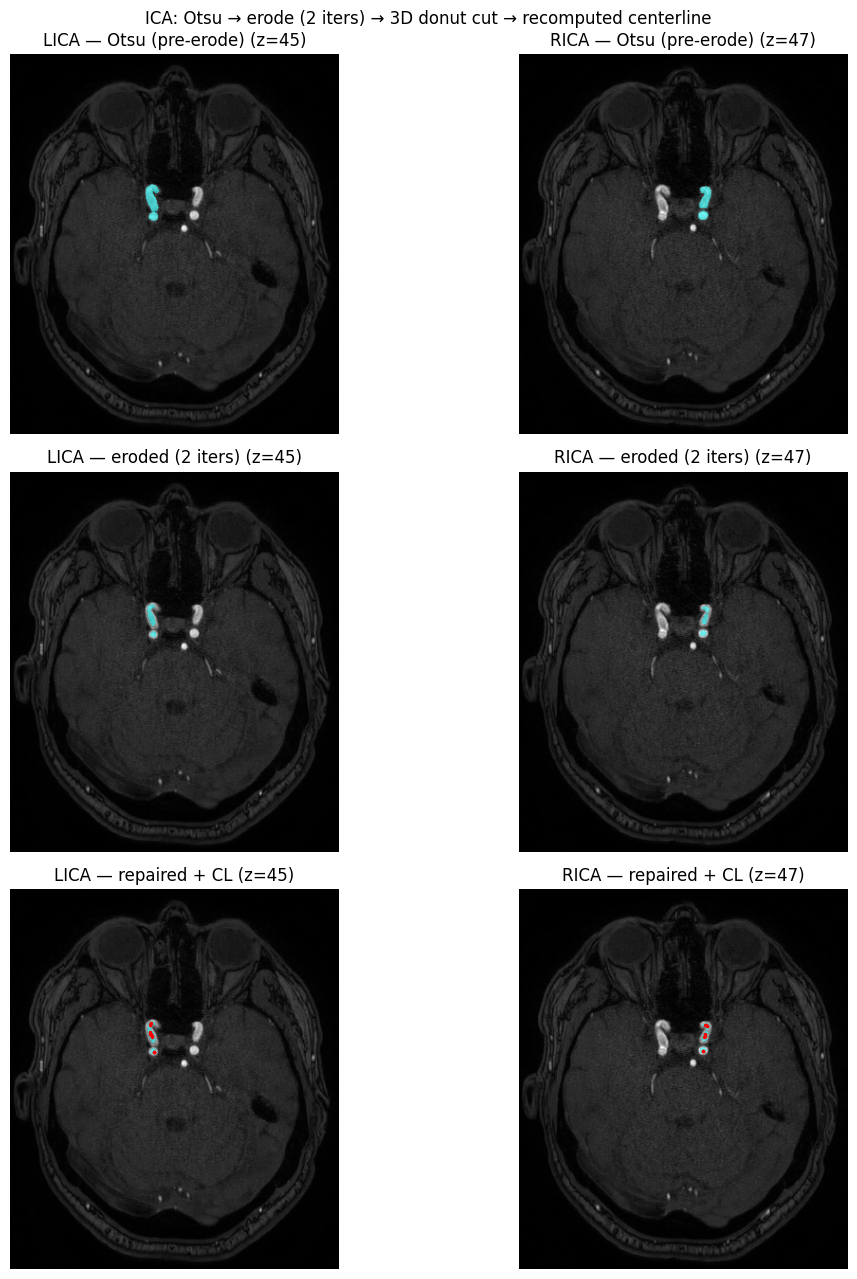

In [9]:
# ============================================================================
# Cell 9 — Final exports + summary table + overview figure
# ============================================================================

log.step("=== Final exports ===")

with core.using("numpy"):
    save_mask_nii(merged.astype(np.int32), OUT_DIR / "TOF_eICAB_CW-ReLABEL.nii.gz", ref=tof)
    save_mask_nii(seg_ica_otsu.astype(np.int32), OUT_DIR / "seg_ica_otsu.nii.gz", ref=tof)
    save_mask_nii(seg_ica_eroded.astype(np.int32), OUT_DIR / "seg_ica_eroded.nii.gz", ref=tof)
    save_mask_nii(seg_ica_repaired.astype(np.int32), OUT_DIR / "seg_ica_repaired.nii.gz", ref=tof)
    save_mask_nii(cl_mask_final.astype(np.int32), OUT_DIR / "centerlines_mask.nii.gz", ref=tof)
log.ok(
    "wrote: TOF_eICAB_CW-ReLABEL.nii.gz | seg_ica_otsu.nii.gz | "
    "seg_ica_eroded.nii.gz | seg_ica_repaired.nii.gz | centerlines_mask.nii.gz"
)

# --- summary table ---
print("\n" + "=" * 110)
print(
    f"{'ICA':6s} {'vox_o':>7s} {'vox_e':>7s} {'vox_r':>7s} "
    f"{'β₁ o→e→r':>10s} {'cyc o→e→r':>12s} "
    f"{'CL_pts':>7s} {'action':>32s}"
)
print("-" * 110)
for lid in ICA_IDS:
    name = bb_vessel_name(lid)
    info = ica_results.get(int(lid), {})
    if not info or info.get("otsu_info", {}).get("warning"):
        print(f"{name:6s} (skipped: {info.get('otsu_info', {}).get('warning', 'missing')})")
        continue
    o = info["otsu_report"]
    e = info["eroded_report"]
    a = info["after"]
    n_o = int(info["otsu_info"].get("n_voxels_pre_erode", o["n_voxels"]))
    n_e = int(info["otsu_info"]["n_voxels"])
    n_r = int(a["n_voxels"])
    n_cl = int(centerlines.get(int(lid), np.empty((0, 3))).shape[0])
    action = info["repair"]["action"]
    b1_str = f"{o['beta1']}→{e['beta1']}→{a['beta1']}"
    cyc_str = f"{o['skeleton_cycles']}→{e['skeleton_cycles']}→{a['skeleton_cycles']}"
    print(
        f"{name:6s} {n_o:7d} {n_e:7d} {n_r:7d} "
        f"{b1_str:>10s} {cyc_str:>12s} {n_cl:7d} {action:>32s}"
    )
print("=" * 110)

# --- overview figure: Otsu → eroded → repaired+CL ---
fig, axes = plt.subplots(3, len(ICA_IDS), figsize=(6 * len(ICA_IDS), 13))
if len(ICA_IDS) == 1:
    axes = np.array([[axes[0]], [axes[1]], [axes[2]]])
for col, lid in enumerate(ICA_IDS):
    name = bb_vessel_name(lid)
    coords_o = np.argwhere(seg_ica_otsu == int(lid))
    coords_r = np.argwhere(seg_ica_repaired == int(lid))
    if coords_o.shape[0] > 0:
        k = int(coords_o[:, 2].mean().round())
    elif coords_r.shape[0] > 0:
        k = int(coords_r[:, 2].mean().round())
    else:
        k = shape[2] // 2

    for row, (seg, label) in enumerate(
        [(seg_ica_otsu, "Otsu (pre-erode)"),
         (seg_ica_eroded, f"eroded ({EROSION_ITERS} iters)"),
         (seg_ica_repaired, "repaired + CL")]
    ):
        axes[row, col].imshow(wvi[:, :, k].T, cmap="gray", origin="lower")
        axes[row, col].imshow(
            np.ma.masked_where(seg[:, :, k] != int(lid), seg[:, :, k]).T,
            alpha=0.5, cmap="cool", origin="lower",
        )
        axes[row, col].set_title(f"{name} — {label} (z={k})")
        axes[row, col].axis("off")
    path = centerlines.get(int(lid), np.empty((0, 3)))
    if path.shape[0] > 0:
        near = np.abs(path[:, 2] - k) <= 1.5
        if near.any():
            axes[2, col].plot(path[near, 0], path[near, 1], "r.", ms=3)

plt.suptitle("ICA: Otsu → erode (2 iters) → 3D donut cut → recomputed centerline")
plt.tight_layout()
plt.show()

## Methodology report

### Problem
The internal carotid arteries (ICAs) feed the anterior circulation through a tortuous
cavernous **siphon**: a roughly tubular segment that climbs the skull base, makes a hairpin
("hook"), and bifurcates into the MCA / ACA. In TOF MRA at our resolution, the two limbs of
the siphon often touch and the multilabel ICA mask **merges** them, turning a topological
hook (β₁ = 0) into a **donut / torus** (β₁ ≥ 1). The centerline of a donut takes the
shortcut through the false bridge, **skipping the apex of the siphon** and therefore the
correct vessel path.

### Empirical prior
For ICAs in our TOF orientation, the false bridge **always closes on the high-Y side** of
the donut (back of the loop). The "true" ICA path is the long arc on the low-Y side. This
prior is what makes the cut unambiguous.

### Pipeline (all 3D)
1. **Relabel eICAB → BB** (`relabel_eicab_to_bb`): merge PCA P1+P2, drop SCA/AChA.
2. **Seed centerlines** for every arterial label
   (`nvitk.morphology.centerline.compute_centerlines`).
3. **Per-ICA Otsu + erosion** (`ica_otsu_mask`):
   - bbox around the seed CL + 7-vox padding,
   - `threshold_otsu` on in-bbox positive intensities,
   - drop CCs < 0.5 % foreground, barrier-dilate other arteries' seed CLs (anti-bleed),
   - `keep_components_touching_seeds` so only the ICA CC that the seed actually passes
     through survives,
   - **`scipy.ndimage.binary_erosion` for `EROSION_ITERS = 2` iterations** —
     this is the cheapest way to break thin donut bridges before the topology check;
     followed by a second `keep_components_touching_seeds` + small-CC cleanup so
     erosion fragments cannot leak into the next stage.
   Two masks are kept: the **raw Otsu** (`01_otsu_*` checkpoints) and the **eroded**
   one (`01b_eroded_*` checkpoints). The eroded mask is what feeds the genus check.
4. **3D genus check** (`compute_genus_3d`): both
   - β₁ from Euler number (assuming β₂ = 0 for tube-like vessels), and
   - the cycle rank of the 26-connected skeleton graph (E − V + C in networkx).
   `suspect = (β₁ > 0) or (skeleton_cycles > 0)`. The two signals catch slightly
   different defects and back each other up. In most cases the 2-iter erosion already
   drives this to 0 — the donut cut is then **skipped** for that ICA.
5. **3D donut cut with Y prior** (`repair_ica_donut_3d`), iterated ≤ 3 times,
   only if step 4 still flags the mask as suspect:
   1. Skeletonize the current mask (`nvitk.morphology.centerline.skeletonize_binary`) and
      build a 26-connected `networkx.Graph` of skeleton voxels.
   2. Find the **shortest** cycle with `networkx.minimum_cycle_basis` (falls back to
      `cycle_basis`). The shortest cycle is the false bridge — the true ICA path is
      open, so the only closed loop is the donut.
   3. **Anchor**: the cycle voxel with the **greatest Y**. If several share the same Y,
      pick the one with the smallest mask distance transform (narrowest neck — DT min as
      tiebreaker only).
   4. **Cut**: subtract a 3D ball at the anchor (radius escalates 1 → 2,
      reduced from the original 1 → 2 → 3 because the erosion already
      removes a 2-voxel "shell" around the whole vessel) until both
      β₁ and skeleton cycle count drop to 0. Each candidate cut is followed by
      `keep_components_touching_seeds` and `remove_small_components_by_fraction` so the
      surviving mask is always anchored on the seed centerline.
   5. Re-skeletonize and iterate if a residual cycle remains (e.g. β₁ ≥ 2).
6. **Topological skeleton-level bridge prune** (`prune_skeleton_shortest_arc`):
   The Y-prior turned out to be orientation-dependent on real subjects (in some
   scans the curl apex sits at the highest-Y, so the prior would carve through
   the *correct* path instead of the bridge). The new prune is **purely
   topological** — independent of any coordinate prior:
   - Skeletonize the (possibly still β₁ > 0) ICA mask.
   - Find every cycle in the skeleton graph (`minimum_cycle_basis`, fallback
     `cycle_basis`); walk each cycle in cyclic order.
   - On each cycle, pick **two anchor nodes** to keep — they are where the
     curl arc terminates:
     - **Degree-3+ junctions** (real branch points where the stem / tip
       attaches to the loop), or
     - if there is only one junction: that junction **plus** the cycle's
       max-Z voxel (the curl apex, future "tip" leaf), or
     - if the cycle is a pure floating loop: the cycle's min-Z and max-Z
       voxels.
   - The cycle splits into **two arcs** at those anchors. The bridge is by
     anatomical definition a *short chord* across the donut hole, while the
     curl is the *long* way around. We therefore **remove the shorter arc**
     from the skeleton (the mask itself is untouched).
   - Every removed voxel is checkpointed as `02c_bridge_voxels.nii.gz`, and
     per-cycle bookkeeping (anchors, arc lengths, Y/Z ranges) lands in
     `02c_centerline_info.json`.
7. **Endpoint-anchored centerline** (`compute_ica_centerline_endpoints`):
   The default `compute_centerlines` walker picks the graph **diameter**
   (double-BFS), which after bridge pruning often terminates at the gap left
   by the removed bridge instead of at the vessel tip. To fix this, the ICA
   centerline is now traced explicitly:
   - In the pruned skeleton (a tree on its main CC), identify the
     **degree-1 leaves**.
   - **`base` = leaf with min Z**, **`tip` = leaf with max Z** — the
     anatomical extremes of the ICA (skull-base entry and bifurcation tip).
   - Compute `networkx.shortest_path(G, base, tip)` — on a tree this is the
     *unique* path, so the centerline always starts and ends at the right
     anatomical points and goes around the full siphon curl.
   - If no degree-1 leaves exist (rare; pure cycles), fall back to min-Z /
     max-Z over all nodes within the largest CC.
8. **Merge** the new ICA centerlines with the non-ICA centerlines and rasterize.

### Why the topological (shortest-arc) prune is robust
- The cycle (skeleton) is a 1D loop. Any cycle has the *bridge* and the *curl*
  as its two arcs — by definition a partial-volume bridge closes the loop with
  a **short chord** while the curl is the **long perimeter**. This is
  invariant under rotation, head tilt, or any scanner-frame quirk that broke
  the Y prior.
- Anchoring on degree-3+ junctions also localises the bridge accurately:
  junctions are exactly where the stem / tip attach to the loop, so anchoring
  on them keeps everything outside the loop intact, while everything between
  them along the short arc is the bridge.
- Using `base = min-Z leaf, tip = max-Z leaf` after the prune guarantees the
  centerline terminates at the vessel extremes (skull-base entry, ICA
  bifurcation) regardless of how the graph diameter happens to fall.

### Performance characteristics
- All heavy work (skeleton, DT, cycle search, marching cubes) runs on the **per-ICA crop**
  (typically ~ 50 × 50 × 100 voxels), not the full TOF volume.
- `minimum_cycle_basis` runs on a graph of a few hundred skeleton voxels — millisecond
  scale.
- One pass per ICA usually suffices; the 3-iteration ceiling is a safety net.
- No 3D MCP routing, no global optimisation — this is what makes it faster than the
  `notebooks/debug/eicab_reseg.ipynb` reference.

### Checkpoint tree (under `OUT_DIR/checkpoints/`)
```
LICA/
  00_seed_centerline.{graphml,npy}        seed eICAB centerline as graph + points
  01_otsu_mask.nii.gz                     RAW Otsu mask (pre-erosion)
  01_otsu_skeleton.graphml                3D skeleton of raw Otsu mask
  01_otsu_surface.vtp                     marching-cubes surface of raw Otsu mask
  01_otsu_genus.json                      β₀, β₁, χ, skeleton cycles, suspect flag
  01_otsu.png                             3-pane axial / coronal / sagittal overlay
  01b_eroded_mask.nii.gz                  Otsu AFTER 2-iter binary erosion
  01b_eroded_skeleton.graphml             3D skeleton of eroded mask
  01b_eroded_surface.vtp                  marching-cubes surface of eroded mask
  01b_eroded_genus.json                   topology summary on eroded mask
  01b_eroded.png                          3-pane overlay of eroded mask
  02_repaired_*                           same set after the (optional) 3D donut cut
  03_centerline.{npy,png}                 ordered centerline (voxel coords) + overlay
  repair_log.json                         dict-serialised RepairLog (iters, anchors, ...)
  repair_iter_0/                          only present if a cut was needed
    before.nii.gz, after.nii.gz           mask before / after this iter's cut
    skeleton.graphml                      3D skeleton at the start of this iter
    cycle.graphml                         the chosen cycle (closed loop)
    cut_anchor.json                       anchor coord, radius, top_y, accepted flag
    surface_after.vtp                     surface after this iter's cut
    after.png                             3-pane overlay centred on the anchor
  ...
RICA/ (same)
```
Top-level NIfTI outputs under `OUT_DIR`:
- `TOF_eICAB_CW-ReLABEL.nii.gz` — full multilabel mask with ICAs replaced by repaired ones.
- `seg_ica_otsu.nii.gz`, `seg_ica_eroded.nii.gz`, `seg_ica_repaired.nii.gz` — ICA-only
  multilabel masks at each stage of the pipeline.
- `centerlines_mask.nii.gz` — rasterised centerlines (one label per artery).

### Visualising `.graphml`, `.npy`, `.vtp`
- **`.graphml` (skeleton / cycle graphs)** — networkx XML. Open as:
  - Python: `import networkx as nx; G = nx.read_graphml(path)` →
    iterate `G.nodes(data=True)` (`x, y, z` attrs) and `G.edges()` and render with
    PyVista (`pv.lines_from_points` per edge) or `matplotlib` 3D scatter.
  - Standalone GUIs: **Gephi**, **yEd**, **Cytoscape** (best for graph layout
    inspection; 3D coordinates are kept as node attributes you can map to position).
  - ParaView via the GraphML reader plugin or by converting to VTK PolyData.
- **`.npy` (centerline coords, shape `(N, 3)`)** — load with `np.load(path)`. Visualise:
  - Python: `pv.Spline(points, n_points=N)` for a smooth tube, or
    `pv.PolyData(points)` for raw nodes, on top of the TOF NIfTI loaded with
    `pv.read("seg_ica_repaired.nii.gz")`.
  - 3D Slicer: convert to a `.fcsv` markup file (one point per row); or as a VTK PolyData
    polyline. Quick conversion: `np.savetxt(path.replace(".npy", ".csv"), pts, fmt="%.3f", delimiter=",")`
    and load CSV via *Markups* in Slicer.
- **`.vtp` (marching-cubes surface)** — open directly in **ParaView**, **3D Slicer**
  (`Models` module), **MeshLab**, or `pv.read(path).plot()` in Python.
- **`.nii.gz` masks** — **3D Slicer**, **ITK-SNAP**, **FSLeyes**, or
  `pv.read(...).slice_orthogonal().plot()` in Python.

A quick all-in-one inspection of one ICA in PyVista:
```python
import pyvista as pv, numpy as np, networkx as nx
ckpt = OUT_DIR / "checkpoints" / "LICA"
surface = pv.read(ckpt / "02_repaired_surface.vtp")
cl_pts = np.load(ckpt / "03_centerline.npy")
G = nx.read_graphml(ckpt / "02_repaired_skeleton.graphml")
sk_pts = np.array([[d["x"], d["y"], d["z"]] for _, d in G.nodes(data=True)])
p = pv.Plotter()
p.add_mesh(surface, opacity=0.4, color="lightblue")
p.add_mesh(pv.PolyData(sk_pts), color="green", point_size=6, render_points_as_spheres=True)
p.add_mesh(pv.Spline(cl_pts, len(cl_pts)), color="red", line_width=4)
p.show()
```

### Limits / known edge cases
- **Multi-handle defects (β₁ ≥ 2)**: handled by iterating the cut; if the residual genus
  cannot be cleared within `MAX_REPAIR_ITERS=3`, the result is flagged `action="partial"`
  in `repair_log.json` for manual review.
- **Y-prior failure**: if a specific subject's siphon orientation differs (e.g. extreme
  head tilt in scanner frame), the high-Y anchor may not land on the bridge. The
  checkpoint `cut_anchor.json` + `cycle.graphml` make this trivial to QC and the radius
  escalation contains the damage.
- **Other arteries (MCA / ACA / PCA / etc.)**: unchanged — they continue to use the
  standard `compute_centerlines` path on the relabelled BB mask.

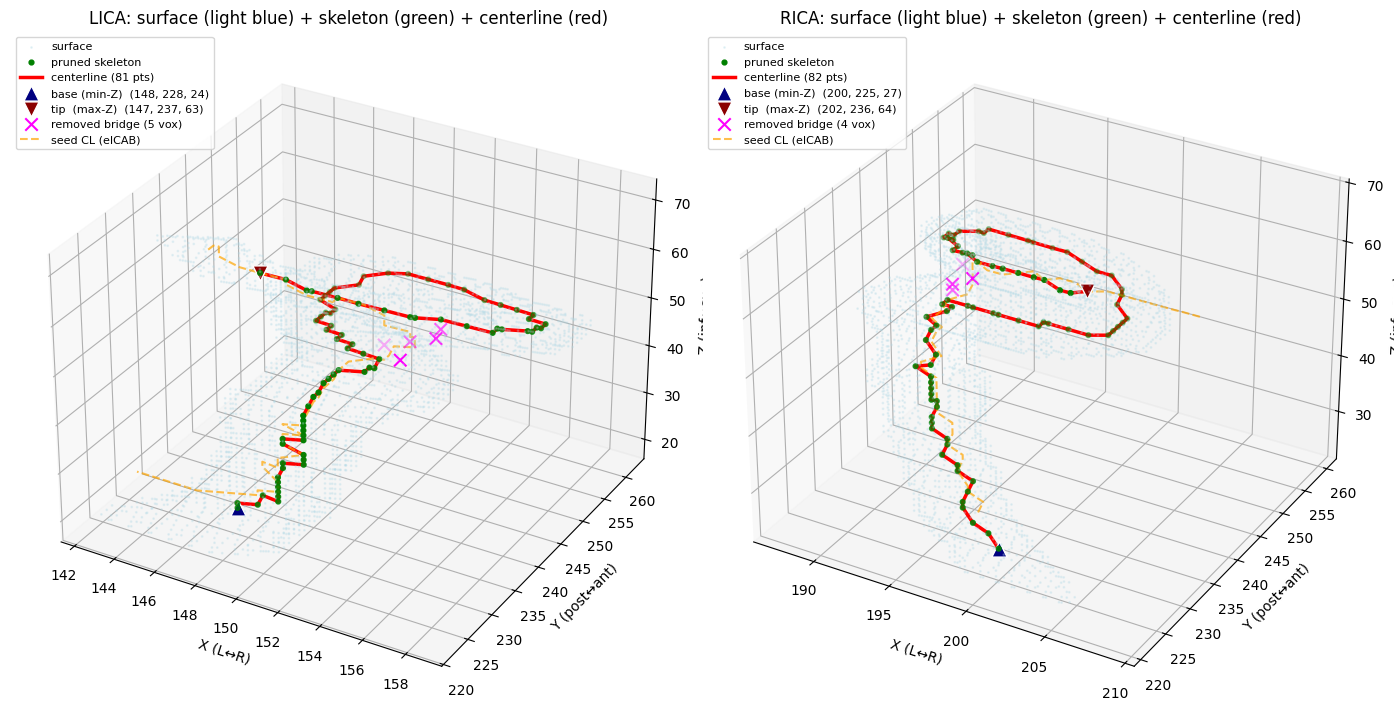

In [10]:
# ============================================================================
# Cell 11 — Inline viewer: load .graphml + .npy + .vtp checkpoints in one figure
# ============================================================================
# Matplotlib 3D (works offline; no live window needed in headless runs).
# For an interactive viewer, swap to PyVista (`pv.Plotter().show()`) — see the
# methodology cell for the exact snippet.

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3d projection)

fig = plt.figure(figsize=(7 * len(ICA_IDS), 8))
for col, lid in enumerate(ICA_IDS):
    name = bb_vessel_name(lid)
    ckpt = CKPT_ROOT / name

    ax = fig.add_subplot(1, len(ICA_IDS), col + 1, projection="3d")
    ax.set_title(f"{name}: surface (light blue) + skeleton (green) + centerline (red)")

    # 1) Surface from VTP (downsampled points)
    surface_file = ckpt / "02_repaired_surface.vtp"
    if surface_file.exists():
        surf = pv.read(str(surface_file))
        pts = np.asarray(surf.points)
        if pts.shape[0] > 8000:
            idx = np.random.default_rng(0).choice(pts.shape[0], 8000, replace=False)
            pts = pts[idx]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=1, c="lightblue", alpha=0.25, label="surface")

    # 2) Pruned skeleton from GraphML
    sk_file = ckpt / "02b_centerline_skeleton.graphml"
    if sk_file.exists():
        G = nx.read_graphml(str(sk_file))
        nodes = np.array(
            [[float(d["x"]), float(d["y"]), float(d["z"])] for _, d in G.nodes(data=True)]
        )
        ax.scatter(nodes[:, 0], nodes[:, 1], nodes[:, 2], s=12, c="green", label="pruned skeleton")

    # 3) Centerline from NPY (base → tip, ordered)
    cl_file = ckpt / "03_centerline.npy"
    if cl_file.exists():
        cl = np.load(cl_file)
        ax.plot(cl[:, 0], cl[:, 1], cl[:, 2], "-", c="red", lw=2.5, label=f"centerline ({len(cl)} pts)")
        ax.scatter(
            cl[:1, 0], cl[:1, 1], cl[:1, 2],
            s=120, c="navy", marker="^", edgecolors="white",
            label=f"base (min-Z)  {tuple(int(v) for v in cl[0])}",
        )
        ax.scatter(
            cl[-1:, 0], cl[-1:, 1], cl[-1:, 2],
            s=120, c="darkred", marker="v", edgecolors="white",
            label=f"tip  (max-Z)  {tuple(int(v) for v in cl[-1])}",
        )

    # 4) Bridge voxels (removed from skeleton). Shown as red Xs to visualise the cut.
    bridge_file = ckpt / "02c_bridge_voxels.nii.gz"
    if bridge_file.exists():
        try:
            bv_img = nv.imread(str(bridge_file), backend="cpu")
            bv_coords = np.argwhere(to_numpy(bv_img.data) > 0)
            if bv_coords.shape[0] > 0:
                ax.scatter(
                    bv_coords[:, 0], bv_coords[:, 1], bv_coords[:, 2],
                    s=80, c="magenta", marker="x",
                    label=f"removed bridge ({bv_coords.shape[0]} vox)",
                )
        except Exception:
            pass

    # 5) Seed centerline (for comparison — shows where eICAB CL went through the bridge)
    seed_file = ckpt / "00_seed_centerline.npy"
    if seed_file.exists():
        seed = np.load(seed_file)
        ax.plot(seed[:, 0], seed[:, 1], seed[:, 2], "--", c="orange", lw=1.5, alpha=0.7, label="seed CL (eICAB)")

    ax.set_xlabel("X (L↔R)")
    ax.set_ylabel("Y (post↔ant)")
    ax.set_zlabel("Z (inf↔sup)")
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()